Importing all necessary libraries in Python 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the data  
df = pd.read_csv('Telco-Customer-Churn.csv')

Inspecting the data. Trying to know more about this data and finding null values and trying to fix 
if there is any problem in that dataset

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Cleaning Process

In [8]:
# converting 'TotalCharges' to numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
# checking if there is any duplicate or not
df.duplicated().sum()

np.int64(0)

In [10]:
df= df.drop_duplicates()

EDA - Univariate Analysis

Numerical Features

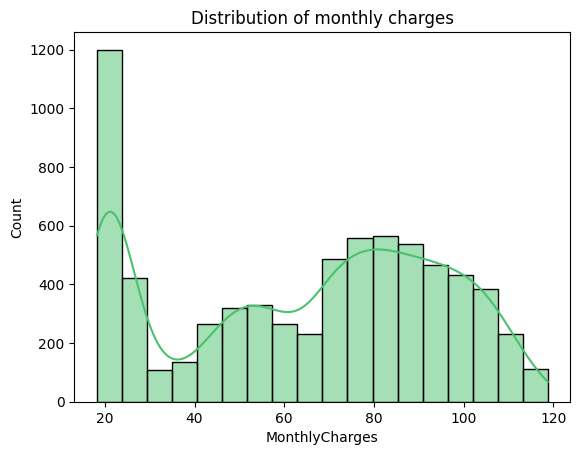

In [11]:
plt.Figure(figsize=(10,6))
sns.histplot(df['MonthlyCharges'],kde=True,color=sns.color_palette("viridis")[4])
plt.title('Distribution of monthly charges')
plt.show()


Text(0.5, 1.0, 'Box plot of tenure')

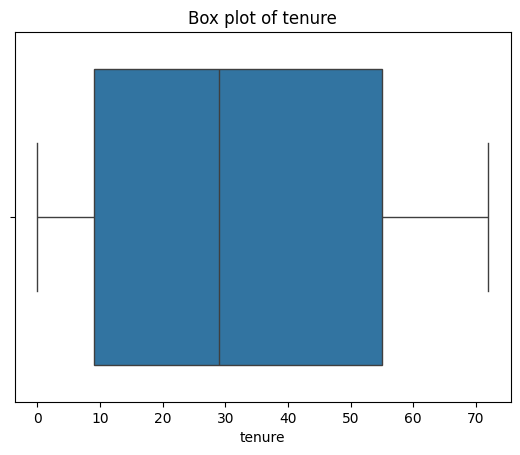

In [12]:
sns.boxplot(x=df['tenure'])
plt.title('Box plot of tenure')

Categorical Features

C:\Users\Akash\AppData\Local\Temp\ipykernel_4432\2524441799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot(x='gender',data=df, palette='viridis')


Text(0.5, 1.0, 'Distribution by Gender')

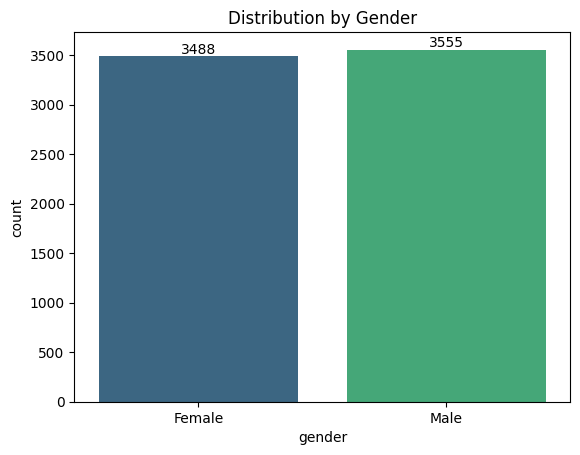

In [13]:
plt.Figure(figsize=(8,6))
ax= sns.countplot(x='gender',data=df, palette='viridis')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Distribution by Gender')

In [14]:
churn_by_gender = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
print(churn_by_gender)


Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603


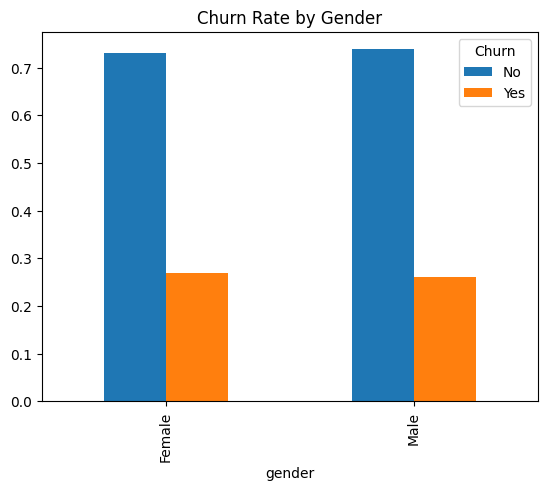

In [15]:
churn_by_gender.plot(kind='bar')
plt.title('Churn Rate by Gender')
plt.show()

Bivarital Analysis

Text(0.5, 1.0, 'Monthly charges vs Churn')

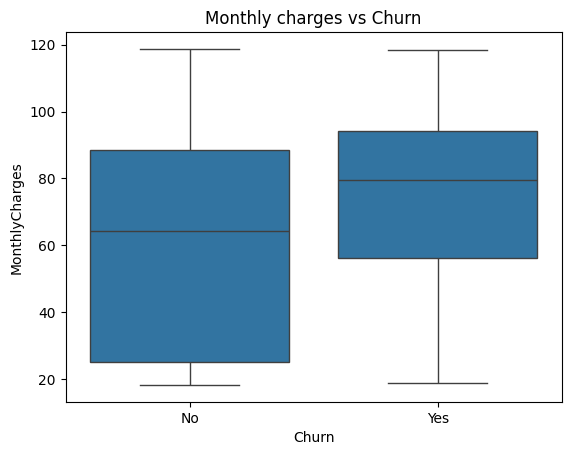

In [16]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Monthly charges vs Churn')

Churn VS Categorical Features

<Axes: xlabel='Contract'>

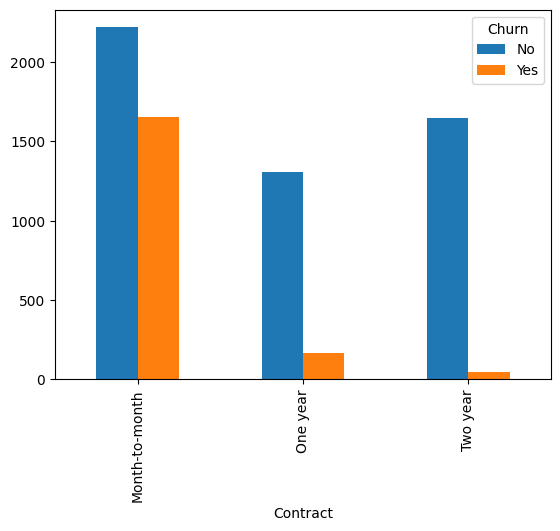

In [17]:
plt.Figure(figsize=(12,6))
pd.crosstab(df['Contract'],df['Churn']).plot(kind='bar')

Multivariate Analysis

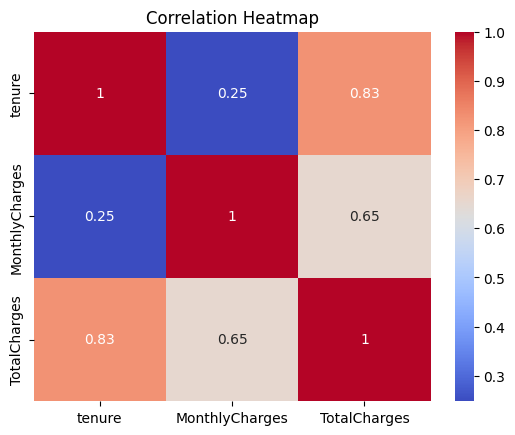

In [18]:
# Heatmap of correlations
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']  # Only numerical for correlation
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



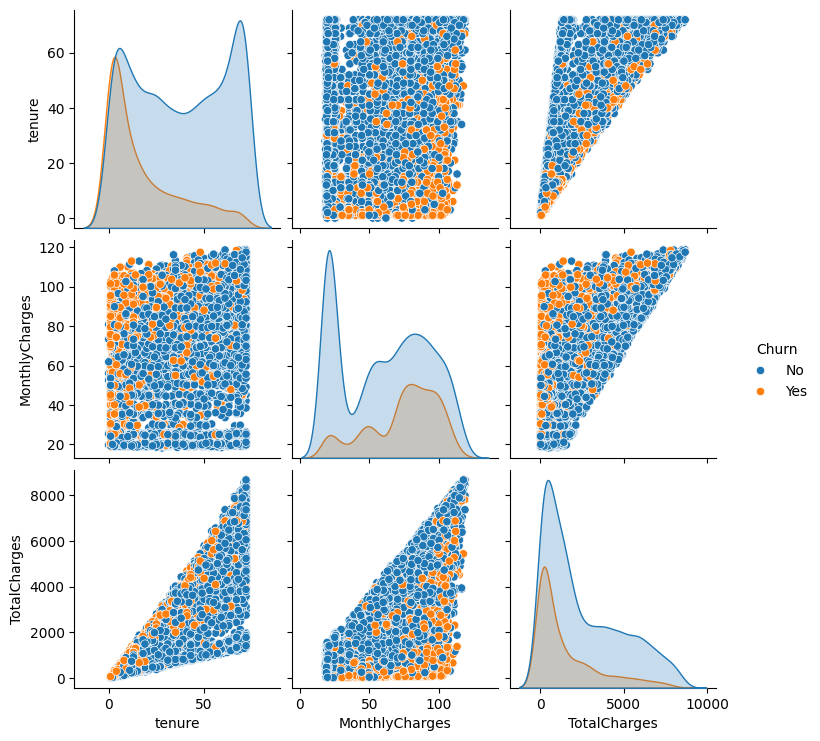

In [19]:
#Pairplot
sns.pairplot(df[numerical_cols + ['Churn']], hue='Churn')
plt.show()

In [21]:
df.to_csv('churn_data.csv', index=False)